In [1]:
# Cell 1: Import Required Packages

!pip install rdkit
!pip install mace-torch
!pip install ASE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 27.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.7 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39449 sha256=c71af878d50193d5f4a56432b35bfd82e1592fab718e579594334b108dc79650
  Stored in directory: /root/.cache/pip/wheels/02/e4/34/75fc0cd5b7889d8cc4ce6fb2f74c9fd17b3c6138cb03832481
Successfully built python-hostlist


In [2]:
# Cell 2: Import Required Libraries

# Tools for plotting charts
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# RDKit is for SMILES to construct a molecule
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import rdMolDescriptors

# ASE (Atomic Simulation Environment) computes information recieved from the machine learning potential
from ase import Atoms, units
from ase.optimize import LBFGS
from ase.vibrations import Vibrations
from ase.thermochemistry import IdealGasThermo

# MACE-OFF is the Machine Learning Potential trained on organic molecules
from mace.calculators import mace_off

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
# Cell 3: Define Molecule using Simplified Molecualr Input Line Entry System (SMILES) to construct it

SMILES = "O=C=O"          # Carbon Dioxide


# Other examples to try:
# SMILES = "CC(=O)O"    # Acetic acid
# SMILES = "c1ccccc1"   # Benzene
# SMILES = "CCCC"       # Butane

TEMPERATURE_K  = 298.15   # Temperature in [K] (temperature focused on in the chart below)
MODEL_SIZE     = "small"  # 'small' (fast) | 'medium' | 'large' (A greater size generally correlates to higher accuracy with the cost of computational time)
DEVICE         = "cpu"    # 'cpu' or 'cuda' (Determines what the code will be running on, a cpu or cuda core (gpu)
FMAX           = 0.01     # eV/Å optimisation threshold use between 0.01 and 0.05 depending on how long the code runs for (higher threshold runs faster)

In [4]:
# Cell 4: Defines Fucntion that takes a SMILES and returns if it is valid.  Then it prints some information about the molecule

SUPPORTED_ELEMENTS = {"C", "H", "N", "O", "F", "Cl", "Br", "S", "P"} # Elements that MACE-OFF is trained on (it should get accurate results with molecules made of these elements)

def validate_smiles(smiles):
    """Validate SMILES and check element compatibility with MACE-OFF."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: '{smiles}'")

    mol = Chem.AddHs(mol)  # add explicit hydrogens
    elements = {atom.GetSymbol() for atom in mol.GetAtoms()}
    unsupported = elements - SUPPORTED_ELEMENTS

    if unsupported:
        raise ValueError(
            f"Unsupported elements for MACE-OFF: {unsupported}\n"
            f"MACE-OFF supports: {SUPPORTED_ELEMENTS}"
        )

    formula = rdMolDescriptors.CalcMolFormula(mol)
    mw = Descriptors.MolWt(mol)
    print(f"  SMILES   : {smiles}")
    print(f"  Formula  : {formula}")
    print(f"  Mol. wt  : {mw:.2f} g/mol")
    print(f"  Elements : {elements}")
    print(f"  MACE-OFF compatible: ✓")
    return mol, formula, mw

print("Validating molecule...")
rdkit_mol, formula, mol_weight = validate_smiles(SMILES)

Validating molecule...
  SMILES   : O=C=O
  Formula  : CO2
  Mol. wt  : 44.01 g/mol
  Elements : {'O', 'C'}
  MACE-OFF compatible: ✓


In [5]:
# Cell 5: Defines Function to Create Atom layout to be optimized later by MACE-OFF

def smiles_to_ase(smiles):
    """Convert SMILES - RDKit 3D - ASE Atoms object."""
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)

    # Embed 3D coordinates
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    result = AllChem.EmbedMolecule(mol, params)
    if result != 0:
        raise RuntimeError("RDKit failed to generate 3D coordinates.")

    # Pre-optimise with MMFF94 (gives MACE-OFF a better starting point)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=2000)

    # Extract positions and elements
    conf = mol.GetConformer()
    positions = conf.GetPositions()   # Angstrom
    symbols   = [atom.GetSymbol() for atom in mol.GetAtoms()]

    return Atoms(symbols=symbols, positions=positions)

atoms = smiles_to_ase(SMILES)
print(f"3D structure generated: {len(atoms)} atoms")
print(f"Symbols: {atoms.get_chemical_symbols()}")

3D structure generated: 3 atoms
Symbols: ['O', 'C', 'O']


In [6]:
# Cell 6: Loads MACE-OFF and moves atoms (slightly) around until the forces on them fall under the input threshold below (this is done to avoid huge forces initially ruining the simulation)

print(f"Loading MACE-OFF ({MODEL_SIZE}) on {DEVICE}...")
calc = mace_off(model=MODEL_SIZE, device=DEVICE)
print("Calculator ready.\n")

# Attach calculator and optimise
atoms.calc = calc
print("Optimising geometry with MACE-OFF...")
opt = LBFGS(atoms, logfile=None)
opt.run(fmax=FMAX)

E0 = atoms.get_potential_energy()   # eV
print(f"Optimisation complete.")
print(f"  Energy        : {E0:.6f} eV")
print(f"  Max force     : {np.max(np.linalg.norm(atoms.get_forces(), axis=1)):.4f} eV/Å")

Loading MACE-OFF (small) on cpu...
The model is distributed under the Academic Software License (ASL) license, see https://github.com/gabor1/ASL 
 To use the model you accept the terms of the license.
ASL is based on the Gnu Public License, but does not permit commercial use
Downloading: 100.0% (7.0 MB / 7.0 MB)
Cached MACE model to /root/.cache/mace/MACE-OFF23_small.model
Using MACE-OFF23 MODEL for MACECalculator with /root/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Calculator ready.

Optimising geometry with MACE-OFF...
Optimisation complete.
  Energy        : -5135.004490 eV
  Max force     : 0.0029 eV/Å


In [7]:
# Cell 7: Finds the potential energy of the molecule including vibrational energy (also filters out imaginary frequencies)

from pathlib import Path
import shutil

# Clear stale cache
shutil.rmtree("vib_cache", ignore_errors=True)

vib_dir = Path("vib_cache")
vib_dir.mkdir(exist_ok=True)

print(f"Running vibrational analysis ({3 * len(atoms)} force evaluations)...")
vib = Vibrations(atoms, name=str(vib_dir / "vib"), delta=0.01)
vib.run()

# Get all energies
vib_energies = vib.get_energies()

# Filter out imaginary and near-zero frequencies
real_vib_energies = vib_energies[vib_energies.real > 0.01]

# Check for too many imaginary modes
n_imaginary = np.sum(vib_energies.real < 0)
if n_imaginary > 2:
    print(f"⚠️  Warning: {n_imaginary} imaginary frequencies detected.")
    print("    Consider tightening FMAX for more reliable results.")
else:
    print(f"✓  {n_imaginary} imaginary mode(s) filtered — looks clean.")

print(f"\nTotal modes      : {len(vib_energies)}")
print(f"Imaginary/zero   : {len(vib_energies) - len(real_vib_energies)}")
print(f"Real modes kept  : {len(real_vib_energies)}")

# Print frequencies manually in cm⁻¹
print("\nVibrational frequencies (real modes):")
freqs_cm = real_vib_energies.real * 8065.54   # eV → cm⁻¹
for i, f in enumerate(freqs_cm):
    print(f"  Mode {i+1:>3d}: {f:>10.2f} cm⁻¹")

Running vibrational analysis (9 force evaluations)...
✓  0 imaginary mode(s) filtered — looks clean.

Total modes      : 9
Imaginary/zero   : 5
Real modes kept  : 4

Vibrational frequencies (real modes):
  Mode   1:     544.67 cm⁻¹
  Mode   2:     545.31 cm⁻¹
  Mode   3:    1248.69 cm⁻¹
  Mode   4:    2170.02 cm⁻¹


In [8]:
# Cell 8: Determines characteristics of the molecule to accurately compute properties



#**** Make sure to change the geometry, symmetry, and spin below in this cell****



thermo = IdealGasThermo(
    vib_energies=real_vib_energies,
    potentialenergy=E0,
    atoms=atoms,
    geometry='linear',  # Change to match molecule (Linear or nonlinear)
    symmetrynumber=2,   # Change to match molecule (how many times you can turn the molecule and have symmetry)
    spin=0,             # Change to match molecule (0.5 times number of unpaired electrons)
)

# Uses the Constant Pressure Enthalpy Equation

# Cp via finite-difference dH/dT
def get_Cp_JmolK(T, dT=1.0):
    H_p = thermo.get_enthalpy(T + dT, verbose=False)
    H_m = thermo.get_enthalpy(T - dT, verbose=False)
    return (H_p - H_m) / (2 * dT) * 96485.3   # eV/K to J/(mol·K)

Cp_ref = get_Cp_JmolK(TEMPERATURE_K)
R = 8.314
Cv_ref = Cp_ref - R

print(f"\n{'='*45}")
print(f"  GAS HEAT CAPACITY — {formula}")
print(f"  T = {TEMPERATURE_K} K")
print(f"{'='*45}")
print(f"  Cₚ = {Cp_ref:>8.2f}  J/(mol·K)")
print(f"  Cᵥ = {Cv_ref:>8.2f}  J/(mol·K)")
print(f"  γ  = {Cp_ref/Cv_ref:>8.4f}")
print(f"{'='*45}")


  GAS HEAT CAPACITY — CO2
  T = 298.15 K
  Cₚ =    39.49  J/(mol·K)
  Cᵥ =    31.17  J/(mol·K)
  γ  =   1.2667


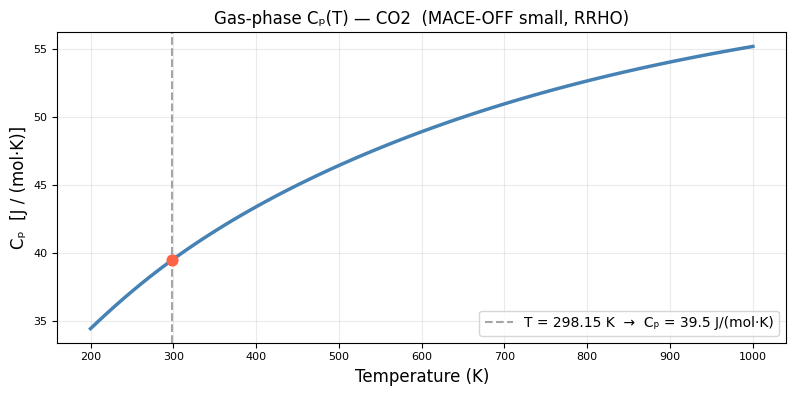

In [9]:
# Cell 9: Cp vs T curve

# Rigid-Rotor Harmonic-Oscillator (Tracks atomic roational energy, not stretching at all, and treats bonds like springs)

# temps is the x-axis range of the graph and Cp_vals calls the function previously used to compute the y value or Cp for all x values, using a step up and step down to compute
temps = np.linspace(200, 1000, 80)
Cp_vals = [get_Cp_JmolK(T) for T in temps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temps, Cp_vals, color="steelblue", lw=2.5)
ax.axvline(TEMPERATURE_K, color="gray", ls="--", alpha=0.7,
           label=f"T = {TEMPERATURE_K} K  →  Cₚ = {Cp_ref:.1f} J/(mol·K)")
ax.scatter([TEMPERATURE_K], [Cp_ref], color="tomato", zorder=5, s=60)
ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Cₚ  [J / (mol·K)]", fontsize=12)
ax.set_title(f"Gas-phase Cₚ(T) — {formula}  (MACE-OFF {MODEL_SIZE}, RRHO)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Error between MACE-OFF and NIST (CO2)

# Compute Cp at multiple temperatures
temps_limits_CO2 = [298, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]
Cp_vals_limits_CO2 = [get_Cp_JmolK(T) for T in temps_limits_CO2]
NIST_Cp_vals_CO2 = [37.12, 37.22, 41.34, 44.61, 47.32, 49.57, 51.44, 53.00, 54.30, 55.40, 56.35]


Cp_vals_limits_CO2 = np.array(Cp_vals_limits_CO2)

data_CO2 = {
    "Temperature in [K]": temps_limits_CO2,
    "Cp [J/mol*K]": Cp_vals_limits_CO2,
    "Percent Error in [%]": np.abs((Cp_vals_limits_CO2 - NIST_Cp_vals_CO2)/NIST_Cp_vals_CO2) * 100,
}

pd.set_option("display.width", 1000)
df = pd.DataFrame(data_CO2)

print(df)

# Comparing Extremely High Temperature Values

# Compute Cp at multiple temperatures
temps_limits_ext_CO2 = [3000, 4000, 5000, 6000]
Cp_vals_limits_ext_CO2 = [get_Cp_JmolK(T) for T in temps_limits_ext_CO2]
NIST_Cp_vals_ext_CO2 = [62.23, 63.25, 64.06, 64.98]


Cp_vals_limits_ext_CO2 = np.array(Cp_vals_limits_ext_CO2)

data_1_CO2 = {
    "Temperature in [K]": temps_limits_ext_CO2,
    "Cp [J/mol*K]": Cp_vals_limits_ext_CO2,
    "Percent Error in [%]": np.abs((Cp_vals_limits_ext_CO2 - NIST_Cp_vals_ext_CO2)/NIST_Cp_vals_ext_CO2) * 100,
}

pd.set_option("display.width", 1000)
df_1 = pd.DataFrame(data_1_CO2)

print("")
print(df_1)

    Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                  298     39.481254              6.361137
1                  300     39.569514              6.312503
2                  400     43.418865              5.028701
3                  500     46.457367              4.141149
4                  600     48.939651              3.422763
5                  700     50.986733              2.858046
6                  800     52.674306              2.399506
7                  900     54.063725              2.007029
8                 1000     55.208434              1.672990
9                 1100     56.154236              1.361438
10                1200     56.939247              1.045691

   Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                3000     61.308486              1.480819
1                4000     61.757324              2.359961
2                5000     61.970529              3.261740
3                6000     62.087835              4.450855


Validating molecule...
  SMILES   : [C-]#[O+]
  Formula  : CO
  Mol. wt  : 28.01 g/mol
  Elements : {'O', 'C'}
  MACE-OFF compatible: ✓
3D structure generated: 2 atoms
Symbols: ['C', 'O']
Optimising geometry with MACE-OFF...
Optimisation complete.
  Energy        : -3083.728132 eV
  Max force     : 0.0004 eV/Å
Running vibrational analysis (6 force evaluations)...
✓  0 imaginary mode(s) filtered — looks clean.

Total modes      : 6
Imaginary/zero   : 5
Real modes kept  : 1

Vibrational frequencies (real modes):
  Mode   1:    2199.85 cm⁻¹

  GAS HEAT CAPACITY — CO
  T = 298.15 K
  Cₚ =    29.12  J/(mol·K)
  Cᵥ =    20.81  J/(mol·K)
  γ  =   1.3995


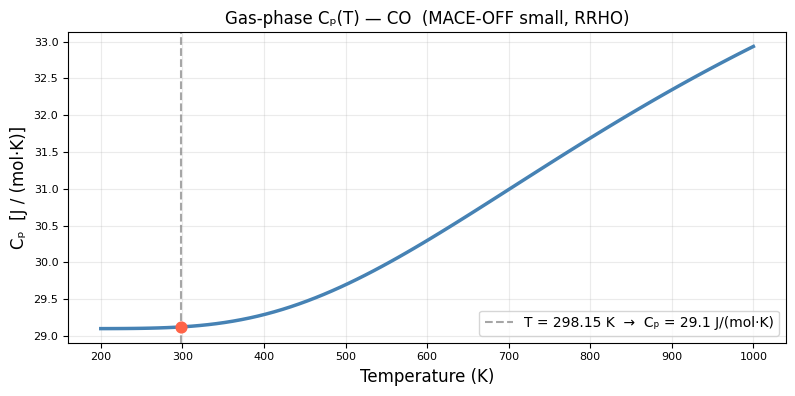

In [11]:
# Cell 11: This will compute the same information for a different gas (Carbon Monoxide) - Remember to change SMILES, symmetry number, and spin number when changing gasses

# You can also change reference Temp (TEMPERATURE_K) to see Cp at different temperatures

SMILES = "[C-]#[O+]"  # Had to play with the SMILES here, C#O did not work (keep this in mind if trying another gas)

TEMPERATURE_K  = 298.15

print("Validating molecule...")
rdkit_mol, formula, mol_weight = validate_smiles(SMILES)

atoms = smiles_to_ase(SMILES)
print(f"3D structure generated: {len(atoms)} atoms")
print(f"Symbols: {atoms.get_chemical_symbols()}")

atoms.calc = calc
print("Optimising geometry with MACE-OFF...")
opt = LBFGS(atoms, logfile=None)
opt.run(fmax=FMAX)

E0 = atoms.get_potential_energy()   # eV
print(f"Optimisation complete.")
print(f"  Energy        : {E0:.6f} eV")
print(f"  Max force     : {np.max(np.linalg.norm(atoms.get_forces(), axis=1)):.4f} eV/Å")



shutil.rmtree("vib_cache", ignore_errors=True)

vib_dir = Path("vib_cache")
vib_dir.mkdir(exist_ok=True)

print(f"Running vibrational analysis ({3 * len(atoms)} force evaluations)...")
vib = Vibrations(atoms, name=str(vib_dir / "vib"), delta=0.01)
vib.run()

# Get all energies
vib_energies = vib.get_energies()

# Filter out imaginary and near-zero frequencies
real_vib_energies = vib_energies[vib_energies.real > 0.01]

# Check for too many imaginary modes
n_imaginary = np.sum(vib_energies.real < 0)
if n_imaginary > 2:
    print(f"⚠️  Warning: {n_imaginary} imaginary frequencies detected.")
    print("    Consider tightening FMAX for more reliable results.")
else:
    print(f"✓  {n_imaginary} imaginary mode(s) filtered — looks clean.")

print(f"\nTotal modes      : {len(vib_energies)}")
print(f"Imaginary/zero   : {len(vib_energies) - len(real_vib_energies)}")
print(f"Real modes kept  : {len(real_vib_energies)}")

# Print frequencies manually in cm⁻¹
print("\nVibrational frequencies (real modes):")
freqs_cm = real_vib_energies.real * 8065.54   # eV → cm⁻¹
for i, f in enumerate(freqs_cm):
    print(f"  Mode {i+1:>3d}: {f:>10.2f} cm⁻¹")


thermo = IdealGasThermo(
    vib_energies=real_vib_energies,
    potentialenergy=E0,
    atoms=atoms,
    geometry='linear',  # Change to match molecule (Linear or nonlinear)
    symmetrynumber=1,   # Change to match molecule (how many times you can turn the molecule and have symmetry)
    spin=1,             # Change to match molecule (0.5 times number of unpaired electrons)
)

Cp_ref = get_Cp_JmolK(TEMPERATURE_K)
R = 8.314
Cv_ref = Cp_ref - R

print(f"\n{'='*45}")
print(f"  GAS HEAT CAPACITY — {formula}")
print(f"  T = {TEMPERATURE_K} K")
print(f"{'='*45}")
print(f"  Cₚ = {Cp_ref:>8.2f}  J/(mol·K)")
print(f"  Cᵥ = {Cv_ref:>8.2f}  J/(mol·K)")
print(f"  γ  = {Cp_ref/Cv_ref:>8.4f}")
print(f"{'='*45}")

temps = np.linspace(200, 1000, 80)
Cp_vals = [get_Cp_JmolK(T) for T in temps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temps, Cp_vals, color="steelblue", lw=2.5)
ax.axvline(TEMPERATURE_K, color="gray", ls="--", alpha=0.7,
           label=f"T = {TEMPERATURE_K} K  →  Cₚ = {Cp_ref:.1f} J/(mol·K)")
ax.scatter([TEMPERATURE_K], [Cp_ref], color="tomato", zorder=5, s=60)
ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Cₚ  [J / (mol·K)]", fontsize=12)
ax.set_title(f"Gas-phase Cₚ(T) — {formula}  (MACE-OFF {MODEL_SIZE}, RRHO)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
#plt.savefig("Cp_vs_T.png", dpi=150)
plt.show()

In [12]:
# Cell 12: Error between MACE-OFF and NIST (CO)

# Compute Cp at multiple temperatures
temps_limits_CO = [298, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300]
Cp_vals_limits_CO = [get_Cp_JmolK(T) for T in temps_limits_CO]
NIST_Cp_vals_CO = [29.15, 29.15, 29.30, 29.82, 30.47, 31.17, 31.88, 32.55, 33.18, 33.73, 34.20, 34.55]


Cp_vals_limits_CO = np.array(Cp_vals_limits_CO)

data_CO = {
    "Temperature in [K]": temps_limits_CO,
    "Cp [J/mol*K]": Cp_vals_limits_CO,
    "Percent Error in [%]": np.abs((Cp_vals_limits_CO - NIST_Cp_vals_CO)/NIST_Cp_vals_CO) * 100,
}

pd.set_option("display.width", 1000)
df = pd.DataFrame(data_CO)

print(df)

# Comparing Extremely High Temperature Values

# Compute Cp at multiple temperatures
temps_limits_ext_CO = [3000, 4000, 5000, 6000]
Cp_vals_limits_ext_CO = [get_Cp_JmolK(T) for T in temps_limits_ext_CO]
NIST_Cp_vals_ext_CO = [37.20, 37.72, 38.07, 38.37]


Cp_vals_limits_ext_CO = np.array(Cp_vals_limits_ext_CO)

data_1_CO = {
    "Temperature in [K]": temps_limits_ext_CO,
    "Cp [J/mol*K]": Cp_vals_limits_ext_CO,
    "Percent Error in [%]": np.abs((Cp_vals_limits_ext_CO - NIST_Cp_vals_ext_CO)/NIST_Cp_vals_ext_CO) * 100,
}

pd.set_option("display.width", 1000)
df_1 = pd.DataFrame(data_1_CO)

print("")
print(df_1)

    Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                  298     29.123484              0.090963
1                  300     29.124837              0.086323
2                  400     29.291302              0.029686
3                  500     29.696333              0.414713
4                  600     30.296759              0.568563
5                  700     30.989528              0.578991
6                  800     31.688677              0.600136
7                  900     32.343927              0.633096
8                 1000     32.933110              0.744094
9                 1100     33.450880              0.827513
10                1200     33.900440              0.875906
11                1300     34.288624              0.756515

   Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                3000     36.684925              1.384611
1                4000     36.994491              1.923408
2                5000     37.142889              2.435279


Validating molecule...
  SMILES   : [H]OO[H]
  Formula  : H2O2
  Mol. wt  : 34.01 g/mol
  Elements : {'O', 'H'}
  MACE-OFF compatible: ✓
3D structure generated: 4 atoms
Symbols: ['O', 'O', 'H', 'H']
Optimising geometry with MACE-OFF...
Optimisation complete.
  Energy        : -4126.604231 eV
  Max force     : 0.0008 eV/Å
Running vibrational analysis (12 force evaluations)...
✓  0 imaginary mode(s) filtered — looks clean.

Total modes      : 12
Imaginary/zero   : 6
Real modes kept  : 6

Vibrational frequencies (real modes):
  Mode   1:     423.91 cm⁻¹
  Mode   2:    1007.43 cm⁻¹
  Mode   3:    1520.81 cm⁻¹
  Mode   4:    1521.78 cm⁻¹
  Mode   5:    3787.79 cm⁻¹
  Mode   6:    3791.16 cm⁻¹

  GAS HEAT CAPACITY — H2O2
  T = 298.15 K
  Cₚ =    41.32  J/(mol·K)
  Cᵥ =    33.00  J/(mol·K)
  γ  =   1.2519


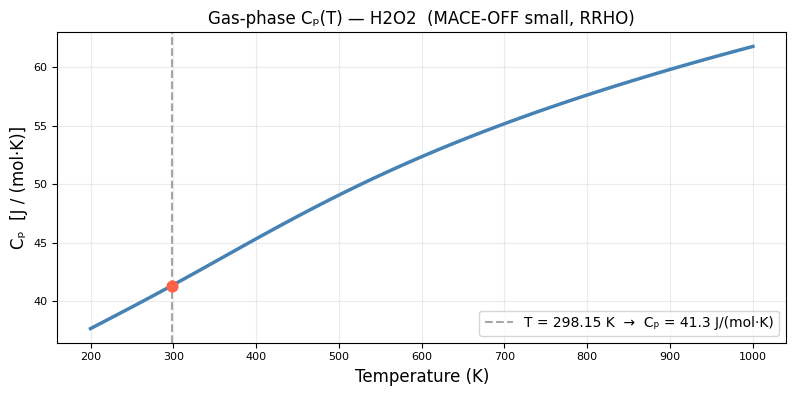

In [13]:
# Cell 13: This will compute the same information for a different gas (Hydrogen Peroxide) - Remember to change SMILES, symmetry number, and spin number when changing gasses

# You can also change reference Temp (TEMPERATURE_K) to see Cp at different temperatures

SMILES = "[H]OO[H]"

TEMPERATURE_K  = 298.15

print("Validating molecule...")
rdkit_mol, formula, mol_weight = validate_smiles(SMILES)

atoms = smiles_to_ase(SMILES)
print(f"3D structure generated: {len(atoms)} atoms")
print(f"Symbols: {atoms.get_chemical_symbols()}")

atoms.calc = calc
print("Optimising geometry with MACE-OFF...")
opt = LBFGS(atoms, logfile=None)
opt.run(fmax=FMAX)

E0 = atoms.get_potential_energy()   # eV
print(f"Optimisation complete.")
print(f"  Energy        : {E0:.6f} eV")
print(f"  Max force     : {np.max(np.linalg.norm(atoms.get_forces(), axis=1)):.4f} eV/Å")



shutil.rmtree("vib_cache", ignore_errors=True)

vib_dir = Path("vib_cache")
vib_dir.mkdir(exist_ok=True)

print(f"Running vibrational analysis ({3 * len(atoms)} force evaluations)...")
vib = Vibrations(atoms, name=str(vib_dir / "vib"), delta=0.01)
vib.run()

# Get all energies
vib_energies = vib.get_energies()

# Filter out imaginary and near-zero frequencies
real_vib_energies = vib_energies[vib_energies.real > 0.01]

# Check for too many imaginary modes
n_imaginary = np.sum(vib_energies.real < 0)
if n_imaginary > 2:
    print(f"⚠️  Warning: {n_imaginary} imaginary frequencies detected.")
    print("    Consider tightening FMAX for more reliable results.")
else:
    print(f"✓  {n_imaginary} imaginary mode(s) filtered — looks clean.")

print(f"\nTotal modes      : {len(vib_energies)}")
print(f"Imaginary/zero   : {len(vib_energies) - len(real_vib_energies)}")
print(f"Real modes kept  : {len(real_vib_energies)}")

# Print frequencies manually in cm⁻¹
print("\nVibrational frequencies (real modes):")
freqs_cm = real_vib_energies.real * 8065.54   # eV → cm⁻¹
for i, f in enumerate(freqs_cm):
    print(f"  Mode {i+1:>3d}: {f:>10.2f} cm⁻¹")


thermo = IdealGasThermo(
    vib_energies=real_vib_energies,
    potentialenergy=E0,
    atoms=atoms,
    geometry='nonlinear', # Change to match molecule (Linear or nonlinear)
    symmetrynumber=2,     # Change to match molecule (how many times you can turn the molecule and have symmetry)
    spin=0,               # Change to match molecule (0.5 times number of unpaired electrons)
)

Cp_ref = get_Cp_JmolK(TEMPERATURE_K)
R = 8.314
Cv_ref = Cp_ref - R

print(f"\n{'='*45}")
print(f"  GAS HEAT CAPACITY — {formula}")
print(f"  T = {TEMPERATURE_K} K")
print(f"{'='*45}")
print(f"  Cₚ = {Cp_ref:>8.2f}  J/(mol·K)")
print(f"  Cᵥ = {Cv_ref:>8.2f}  J/(mol·K)")
print(f"  γ  = {Cp_ref/Cv_ref:>8.4f}")
print(f"{'='*45}")

temps = np.linspace(200, 1000, 80)
Cp_vals = [get_Cp_JmolK(T) for T in temps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temps, Cp_vals, color="steelblue", lw=2.5)
ax.axvline(TEMPERATURE_K, color="gray", ls="--", alpha=0.7,
           label=f"T = {TEMPERATURE_K} K  →  Cₚ = {Cp_ref:.1f} J/(mol·K)")
ax.scatter([TEMPERATURE_K], [Cp_ref], color="tomato", zorder=5, s=60)
ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Cₚ  [J / (mol·K)]", fontsize=12)
ax.set_title(f"Gas-phase Cₚ(T) — {formula}  (MACE-OFF {MODEL_SIZE}, RRHO)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
#plt.savefig("Cp_vs_T.png", dpi=150)
plt.show()

In [14]:
# Cell 14: Error between MACE-OFF and NIST (H2O2)

# Compute Cp at multiple temperatures
temps_limits_H2O2 = [298, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
Cp_vals_limits_H2O2 = [get_Cp_JmolK(T) for T in temps_limits_H2O2]
NIST_Cp_vals_H2O2 = [43.07, 43.20, 48.65, 52.51, 55.50, 57.92, 59.90, 61.55, 62.95, 64.17, 65.27, 66.30, 67.33, 68.42]

Cp_vals_limits_H2O2 = np.array(Cp_vals_limits_H2O2)

print(Cp_vals_limits_H2O2)

data_H2O2 = {
    "Temperature in [K]": temps_limits_H2O2,
    "Cp [J/mol*K]": Cp_vals_limits_H2O2,
    "Percent Error in [%]": np.abs((Cp_vals_limits_H2O2 - NIST_Cp_vals_H2O2)/NIST_Cp_vals_H2O2) * 100,
}

pd.set_option("display.width", 1000)
df = pd.DataFrame(data_H2O2)

print(df)

[41.31222439 41.38958943 45.32203054 49.0639611  52.34718499 55.16971412
 57.62726042 59.8101861  61.77823031 63.56603628 65.19373796 66.67470747
 68.0197902  69.2391612 ]
    Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                  298     41.312224              4.081206
1                  300     41.389589              4.190765
2                  400     45.322031              6.840636
3                  500     49.063961              6.562634
4                  600     52.347185              5.680748
5                  700     55.169714              4.748422
6                  800     57.627260              3.794223
7                  900     59.810186              2.826668
8                 1000     61.778230              1.861429
9                 1100     63.566036              0.941193
10                1200     65.193738              0.116841
11                1300     66.674707              0.565170
12                1400     68.019790              1.024492
13

Validating molecule...
  SMILES   : C
  Formula  : CH4
  Mol. wt  : 16.04 g/mol
  Elements : {'H', 'C'}
  MACE-OFF compatible: ✓
3D structure generated: 5 atoms
Symbols: ['C', 'H', 'H', 'H', 'H']
Optimising geometry with MACE-OFF...
Optimisation complete.
  Energy        : -1103.060024 eV
  Max force     : 0.0016 eV/Å
Running vibrational analysis (15 force evaluations)...
✓  0 imaginary mode(s) filtered — looks clean.

Total modes      : 15
Imaginary/zero   : 6
Real modes kept  : 9

Vibrational frequencies (real modes):
  Mode   1:    1329.32 cm⁻¹
  Mode   2:    1329.40 cm⁻¹
  Mode   3:    1329.56 cm⁻¹
  Mode   4:    1546.79 cm⁻¹
  Mode   5:    1546.97 cm⁻¹
  Mode   6:    3046.53 cm⁻¹
  Mode   7:    3166.93 cm⁻¹
  Mode   8:    3167.10 cm⁻¹
  Mode   9:    3167.34 cm⁻¹

  GAS HEAT CAPACITY — CH4
  T = 298.15 K
  Cₚ =    35.48  J/(mol·K)
  Cᵥ =    27.16  J/(mol·K)
  γ  =   1.3061


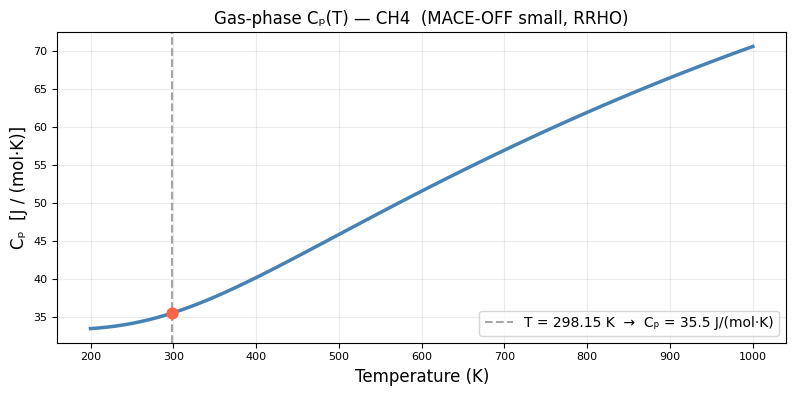

In [15]:
# Cell 15: This will compute the same information for a different gas (Methane) - Remember to change SMILES, symmetry number, and spin number when changing gasses

# You can also change reference Temp (TEMPERATURE_K) to see Cp at different temperatures

SMILES = "C"

TEMPERATURE_K  = 298.15

print("Validating molecule...")
rdkit_mol, formula, mol_weight = validate_smiles(SMILES)

atoms = smiles_to_ase(SMILES)
print(f"3D structure generated: {len(atoms)} atoms")
print(f"Symbols: {atoms.get_chemical_symbols()}")

atoms.calc = calc
print("Optimising geometry with MACE-OFF...")
opt = LBFGS(atoms, logfile=None)
opt.run(fmax=FMAX)

E0 = atoms.get_potential_energy()   # eV
print(f"Optimisation complete.")
print(f"  Energy        : {E0:.6f} eV")
print(f"  Max force     : {np.max(np.linalg.norm(atoms.get_forces(), axis=1)):.4f} eV/Å")



shutil.rmtree("vib_cache", ignore_errors=True)

vib_dir = Path("vib_cache")
vib_dir.mkdir(exist_ok=True)

print(f"Running vibrational analysis ({3 * len(atoms)} force evaluations)...")
vib = Vibrations(atoms, name=str(vib_dir / "vib"), delta=0.01)
vib.run()

# Get all energies
vib_energies = vib.get_energies()

# Filter out imaginary and near-zero frequencies
real_vib_energies = vib_energies[vib_energies.real > 0.01]

# Check for too many imaginary modes
n_imaginary = np.sum(vib_energies.real < 0)
if n_imaginary > 2:
    print(f"⚠️  Warning: {n_imaginary} imaginary frequencies detected.")
    print("    Consider tightening FMAX for more reliable results.")
else:
    print(f"✓  {n_imaginary} imaginary mode(s) filtered — looks clean.")

print(f"\nTotal modes      : {len(vib_energies)}")
print(f"Imaginary/zero   : {len(vib_energies) - len(real_vib_energies)}")
print(f"Real modes kept  : {len(real_vib_energies)}")

# Print frequencies manually in cm⁻¹
print("\nVibrational frequencies (real modes):")
freqs_cm = real_vib_energies.real * 8065.54   # eV → cm⁻¹
for i, f in enumerate(freqs_cm):
    print(f"  Mode {i+1:>3d}: {f:>10.2f} cm⁻¹")


thermo = IdealGasThermo(
    vib_energies=real_vib_energies,
    potentialenergy=E0,
    atoms=atoms,
    geometry='nonlinear', # Change to match molecule (Linear or nonlinear)
    symmetrynumber=12,     # Change to match molecule (how many times you can turn the molecule and have symmetry)
    spin=0,               # Change to match molecule (0.5 times number of unpaired electrons)
)

Cp_ref = get_Cp_JmolK(TEMPERATURE_K)
R = 8.314
Cv_ref = Cp_ref - R

print(f"\n{'='*45}")
print(f"  GAS HEAT CAPACITY — {formula}")
print(f"  T = {TEMPERATURE_K} K")
print(f"{'='*45}")
print(f"  Cₚ = {Cp_ref:>8.2f}  J/(mol·K)")
print(f"  Cᵥ = {Cv_ref:>8.2f}  J/(mol·K)")
print(f"  γ  = {Cp_ref/Cv_ref:>8.4f}")
print(f"{'='*45}")

temps = np.linspace(200, 1000, 80)
Cp_vals = [get_Cp_JmolK(T) for T in temps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temps, Cp_vals, color="steelblue", lw=2.5)
ax.axvline(TEMPERATURE_K, color="gray", ls="--", alpha=0.7,
           label=f"T = {TEMPERATURE_K} K  →  Cₚ = {Cp_ref:.1f} J/(mol·K)")
ax.scatter([TEMPERATURE_K], [Cp_ref], color="tomato", zorder=5, s=60)
ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Cₚ  [J / (mol·K)]", fontsize=12)
ax.set_title(f"Gas-phase Cₚ(T) — {formula}  (MACE-OFF {MODEL_SIZE}, RRHO)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
#plt.savefig("Cp_vs_T.png", dpi=150)
plt.show()

In [16]:
# Cell 16: Error between MACE-OFF and NIST (CH4)

# Compute Cp at multiple temperatures
temps_limits_CH4 = [298, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300]
Cp_vals_limits_CH4 = [get_Cp_JmolK(T) for T in temps_limits_CH4]
NIST_Cp_vals_CH4 = [35.69, 35.76, 40.63, 46.63, 52.74, 58.60, 64.08, 69.14, 73.75, 77.92, 81.68, 85.07]


Cp_vals_limits_CH4 = np.array(Cp_vals_limits_CH4)

data_CH4 = {
    "Temperature in [K]": temps_limits_CH4,
    "Cp [J/mol*K]": Cp_vals_limits_CH4,
    "Percent Error in [%]": np.abs((Cp_vals_limits_CH4 - NIST_Cp_vals_CH4)/NIST_Cp_vals_CH4) * 100,
}

pd.set_option("display.width", 1000)
df = pd.DataFrame(data_CH4)

print(df)

# Comparing Extremely High Temperature Values

# Compute Cp at multiple temperatures
temps_limits_ext_CH4 = [2000, 2500, 3000]
Cp_vals_limits_ext_CH4 = [get_Cp_JmolK(T) for T in temps_limits_ext_CH4]
NIST_Cp_vals_ext_CH4 = [101.24, 108.23, 113.55]


Cp_vals_limits_ext_CH4 = np.array(Cp_vals_limits_ext_CH4)

data_1_CH4 = {
    "Temperature in [K]": temps_limits_ext_CH4,
    "Cp [J/mol*K]": Cp_vals_limits_ext_CH4,
    "Percent Error in [%]": np.abs((Cp_vals_limits_ext_CH4 - NIST_Cp_vals_ext_CH4)/NIST_Cp_vals_ext_CH4) * 100,
}

pd.set_option("display.width", 1000)
df_1 = pd.DataFrame(data_1_CO)

print("")
print(df_1)

    Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                  298     35.471427              0.612420
1                  300     35.541741              0.610345
2                  400     40.161323              1.153525
3                  500     45.839422              1.695428
4                  600     51.548170              2.259821
5                  700     56.936600              2.838567
6                  800     61.916711              3.375919
7                  900     66.467289              3.865652
8                 1000     70.586276              4.289795
9                 1100     74.284478              4.665711
10                1200     77.583887              5.014829
11                1300     80.514526              5.354972

   Temperature in [K]  Cp [J/mol*K]  Percent Error in [%]
0                3000     36.684925              1.384611
1                4000     36.994491              1.923408
2                5000     37.142889              2.435279
